# Fake Job Posting Detector

Goal: classify a job posting as **real (0)** or **fake (1)**. The data is heavily
imbalanced (~4.8% fakes), so the project is about catching fakes (recall/F1 of the
fake class), not raw accuracy. We start with a deliberately dumb baseline and
improve it step by step.

## 1. Setup & load data

In [2]:
import pandas as pd
import numpy as np
import joblib

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, recall_score, f1_score, roc_auc_score, classification_report,
)

data = pd.read_csv("data/fake_job_postings.csv")

print("Shape:", data.shape)
print("\nTarget distribution (fraudulent):")
print(data["fraudulent"].value_counts())
print("\nShare of fakes: {:.1%}".format(data["fraudulent"].mean()))

Shape: (17880, 18)

Target distribution (fraudulent):
fraudulent
0    17014
1      866
Name: count, dtype: int64

Share of fakes: 4.8%


## 2. Text preprocessing

Fill missing values, then glue the main text fields into one `text` column that
the model will read. `y` is the target.

In [3]:
data = data.fillna("")   # NaN + text = NaN, so fill gaps first

# one text string per posting
data["text"] = (
    data["title"] + " " + data["company_profile"] + " "
    + data["description"] + " " + data["requirements"]
)
y = data["fraudulent"]

print("Empty texts:", data["text"].isna().sum())   # should be 0
data[["text"]].head(3)

Empty texts: 0


,text
0,"Marketing Intern We're Food52, and we've creat..."
1,Customer Service - Cloud Video Production 90 S...
2,Commissioning Machinery Assistant (CMA) Valor ...


## 3. Train / test split

One split, reused by every model so the comparison is fair. `stratify=y` keeps the
4.8% fake ratio in both train and test.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    data["text"], y, test_size=0.2, random_state=42, stratify=y
)
print("train:", X_train.shape[0], "| test:", X_test.shape[0])

train: 14304 | test: 3576


## 4. Evaluation helper (improvement tracker)

Defined once, before any model. Every iteration calls `log_result(...)`, so the
`results` table grows into our "improvement over time" overview.

In [5]:
results = []  # one row per iteration

def log_result(name, fitted_model, X_test, y_test):
    """Compute all metrics for a fitted model and add one row to the results table."""
    y_pred = fitted_model.predict(X_test)
    y_proba = fitted_model.predict_proba(X_test)[:, 1]   # probability of "fake"
    results.append({
        "iteration":   name,
        "accuracy":    round(accuracy_score(y_test, y_pred), 3),
        "fake_recall": round(recall_score(y_test, y_pred), 3),
        "fake_f1":     round(f1_score(y_test, y_pred), 3),
        "roc_auc":     round(roc_auc_score(y_test, y_proba), 3),
    })
    return pd.DataFrame(results)

## 5. Iteration 0 — idiotic baseline

The simplest pipeline: TF-IDF (tokenise) → TruncatedSVD (reduce dimensions) →
Logistic Regression. No imbalance handling yet — this is our benchmark.

In [6]:
model = Pipeline([
    ("tfidf", TfidfVectorizer(stop_words="english", max_df=0.9, min_df=5)),
    ("svd", TruncatedSVD(n_components=100, random_state=42)),
    ("clf", LogisticRegression(max_iter=1000)),
]).fit(X_train, y_train)

/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/extmath.py:619: RuntimeWarning: divide by zero encountered in matmul
  U = Q @ Uhat
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/extmath.py:619: RuntimeWarning: overflow encountered in matmul
  U = Q @ Uhat
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/extmath.py:619: RuntimeWarning: invalid value encountered in matmul
  U = Q @ Uhat
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:219: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights_xp + intercept_xp
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:219: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights_xp + intercept_xp
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:219: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights_xp + intercept_xp
/opt/anaconda3/lib/pytho

In [7]:
# detailed per-class report for the baseline (shown once for insight)
print(classification_report(model.predict(X_test), y_test, target_names=["real (0)", "fake (1)"]))

              precision    recall  f1-score   support

    real (0)       1.00      0.96      0.98      3542
    fake (1)       0.20      1.00      0.33        34

    accuracy                           0.96      3576
   macro avg       0.60      0.98      0.65      3576
weighted avg       0.99      0.96      0.97      3576



/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/extmath.py:229: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/extmath.py:229: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/extmath.py:229: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


In [8]:
log_result("0 - baseline (TFIDF + SVD + LogReg)", model, X_test, y_test)

/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/extmath.py:229: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/extmath.py:229: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/extmath.py:229: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/extmath.py:229: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/extmath.py:229: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/extmath.py:229: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


,iteration,accuracy,fake_recall,fake_f1,roc_auc
0,0 - baseline (TFIDF + SVD + LogReg),0.961,0.197,0.329,0.902


## 6. Iteration 1 — handle class imbalance

The baseline ignores the rare fake class. `class_weight="balanced"` makes the model
penalise mistakes on fakes more heavily, so the fake recall should rise (accuracy may
drop slightly — that trade-off is fine and expected).

In [9]:
model_balanced = Pipeline([
    ("tfidf", TfidfVectorizer(stop_words="english", max_df=0.9, min_df=5)),
    ("svd", TruncatedSVD(n_components=100, random_state=42)),
    ("clf", LogisticRegression(max_iter=1000, class_weight="balanced")),
]).fit(X_train, y_train)

log_result("1 - class_weight balanced", model_balanced, X_test, y_test)

/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/extmath.py:619: RuntimeWarning: divide by zero encountered in matmul
  U = Q @ Uhat
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/extmath.py:619: RuntimeWarning: overflow encountered in matmul
  U = Q @ Uhat
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/extmath.py:619: RuntimeWarning: invalid value encountered in matmul
  U = Q @ Uhat
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:219: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights_xp + intercept_xp
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:219: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights_xp + intercept_xp
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_linear_loss.py:219: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights_xp + intercept_xp
/opt/anaconda3/lib/pytho

,iteration,accuracy,fake_recall,fake_f1,roc_auc
0,0 - baseline (TFIDF + SVD + LogReg),0.961,0.197,0.329,0.902
1,1 - class_weight balanced,0.833,0.855,0.332,0.919


## 7. Save model (for the Streamlit app)

We save the current model so `app.py` can load it. Re-run this with the best model
once we settle on a final one.

In [10]:
joblib.dump(model, "fake_job_model.joblib")
print("saved fake_job_model.joblib")

saved fake_job_model.joblib


## 8. Feature engineering — lemmatising & word analysis

Improve the text features before the big model search:
1. Lemmatise (reduce words to their base form).
2. Find words that are equally frequent in real & fake postings (noise → remove)
   vs. words whose frequency differs a lot between classes (signal).

In [ ]:
# Block A1
import re
import nltk
nltk.download("wordnet", quiet=True)
nltk.download("omw-1.4", quiet=True)
from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()

def lemmatize_text(text):
    # lowercase, keep only letter-tokens, reduce each word to its base form
    tokens = re.findall(r"[a-z]+", text.lower())
    return " ".join(lemmatizer.lemmatize(t) for t in tokens)

# new column with the cleaned, lemmatised text
data['text_lemmatized'] = data['text'].apply(lemmatize_text)

data[['text', 'text_lemmatized']].head(3)


,text,text_lemmatized
0,"Marketing Intern We're Food52, and we've creat...",marketing intern we re food and we ve created ...
1,Customer Service - Cloud Video Production 90 S...,customer service cloud video production second...
2,Commissioning Machinery Assistant (CMA) Valor ...,commissioning machinery assistant cma valor se...


- re.findall(r"[a-z]+", text.lower()) = simples Tokenizing: alles klein, nur Buchstaben-Wörter (wirft Zahlen/Satzzeichen raus).

- WordNetLemmatizer bringt Wörter auf die Grundform (jobs → job, working → working*) — so zählen Varianten als ein Feature, das Vokabular wird kleiner und sauberer.

- (*Hinweis: ohne POS-Tag lemmatisiert WordNet standardmäßig als Substantiv, Verben bleiben teils stehen. Das reicht für unseren Zweck völlig — die fortgeschrittene POS-Variante erwähnen wir später, falls die Dozentin fragt.)
Wir schreiben das Ergebnis in eine neue Spalte text_lemmatized und lassen text im Original stehen — so kannst du jederzeit vergleichen.

⚠️ Das apply läuft über 17.880 Anzeigen → dauert ~1–2 Minuten, ist normal. Wenn der Output zwei Spalten zeigt (Original vs. lemmatisiert), hat's geklappt.

In [14]:
# Block A2
from collections import Counter

# count word frequencies separately in real (0) and fake (1) postings
real_words = Counter(" ".join(data.loc[data['fraudulent']==0, 'text_lemmatized']).split())
fake_words = Counter(" ".join(data.loc[data['fraudulent']==1, 'text_lemmatized']).split())

# normalise to a RATE per class (there are far more real postings, so raw counts would lie)
real_total, fake_total = sum(real_words.values()), sum(fake_words.values())

vocab = set(real_words) | set(fake_words) 
freq = pd.DataFrame({'word': list(vocab)})
freq['real_rate'] = freq['word'].map(lambda w: real_words[w] / real_total)
freq['fake_rate'] = freq['word'].map(lambda w: fake_words[w] / fake_total)
# how differently used
freq['diff']      = (freq['fake_rate'] - freq['real_rate']).abs() 
# how frequent overall
freq['total_rate'] = freq['real_rate'] + freq['fake_rate']

# SET A - NOISE: frequent overall BUT used at similiar rate in both classes -> no signal -> remove
noise_words = freq[(freq['total_rate'] > freq['total_rate'].quantile(0.95)) &
                    (freq['diff']      < freq['diff'].quantile(0.5))]['word'].tolist()

# SET B - SIGNAL: biggest frequency difference between classes -> the discriminating words
signal_words = freq.sort_values('diff', ascending=False).head(20)

print(f"Noise words to remove: {len(noise_words)}")
print("Examples:", noise_words[:15])
print("\nTop signal words (fake vs real rate):")
print(signal_words[["word", "real_rate", "fake_rate"]].to_string(index=False))

Noise words to remove: 14
Examples: ['aligned', 'setup', 'suggest', 'siemens', 'contacted', 'provides', 'succession', 'collect', 'farm', 'critical', 'trial', 'smile', 'personality', 'bf']

Top signal words (fake vs real rate):
       word  real_rate  fake_rate
         we   0.010901   0.006268
        our   0.009662   0.005201
        the   0.029292   0.026244
        amp   0.002126   0.004539
        you   0.008365   0.005982
         of   0.021856   0.019540
          a   0.029259   0.027017
      skill   0.002992   0.004962
engineering   0.000798   0.002656
          e   0.003326   0.005167
       team   0.005537   0.003702
         it   0.003199   0.001375
       work   0.005160   0.006960
       that   0.005059   0.003288
         is   0.009247   0.007490
        and   0.052154   0.053901
     system   0.001511   0.003245
   position   0.001679   0.003408
         re   0.001983   0.000427
       will   0.004732   0.003203


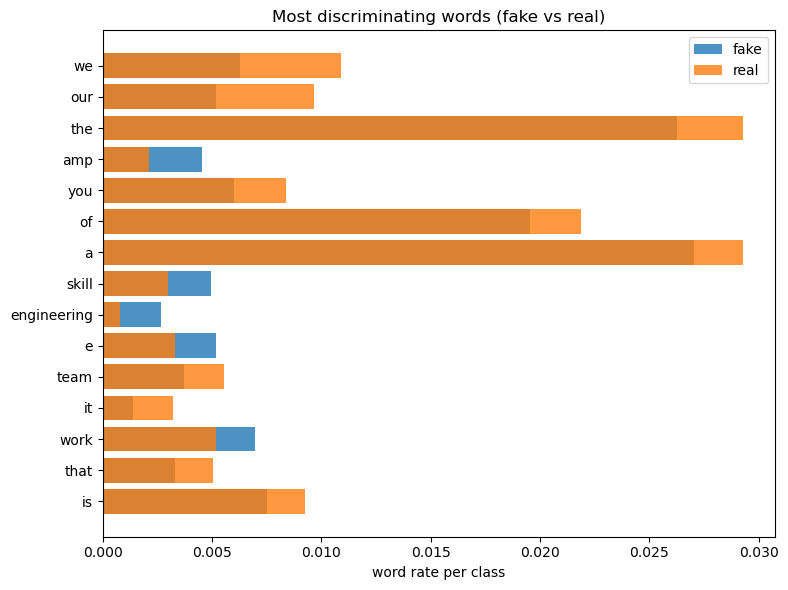

In [15]:
# Block A3

import matplotlib.pyplot as plt

top = freq.sort_values("diff", ascending=False).head(15).sort_values("diff")
plt.figure(figsize=(8, 6))
plt.barh(top["word"], top["fake_rate"], label="fake", alpha=0.8)
plt.barh(top["word"], top["real_rate"], label="real", alpha=0.8)
plt.xlabel("word rate per class"); plt.title("Most discriminating words (fake vs real)")
plt.legend(); plt.tight_layout(); plt.show()

## 9. Systematic model search (pipelines + grids + performance matrix)

Build a list of pipelines, give each a parameter grid, run GridSearchCV on all of
them, and collect every model's metrics into one performance table via `.apply()`.

In [ ]:
# Block B1 - Pipelines & Param-Grids definition
from sklearn.model_selection import GridSearchCV
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# combine sklearn's emglish stopwords with own noise words
custom_stop = list(ENGLISH_STOP_WORDS.union(noise_words))

# resplit on the LEMMATISED text (input for all models --> yay i made it to here)
X_train, X_test, y_train, y_test = train_test_split(
    data["text_lemmatized"], y, test_size=0.2, random_state=42, stratify=y
)

# one entry per model: name, pipeline, parameter grid
configs = pd.DataFrame([
    {"name": "LogReg",
     "pipeline": Pipeline([("tfidf", TfidfVectorizer(stop_words=custom_stop)),
                           ("clf", LogisticRegression(max_iter=1000))]),
    "grid": {"tfidf__ngram_range": [(1,1), (1,2)], "tfidf__min_df": [3,5],
             "clf__C": [0.01, 0.1, 1, 10], "clf__class_weight": [None, "balanced"]}},

    {"name": "LinearSVC",
     "pipeline": Pipeline([("tfidf", TfidfVectorizer(stop_words=custom_stop)),
                           ("clf", LinearSVC(max_iter=3000))]),
     "grid": {"tfidf__ngram_range": [(1,1),(1,2)], "tfidf__min_df": [3,5],
              "clf__C": [0.01,0.1,1,10], "clf__class_weight": [None,"balanced"]}},
    
    {"name": "MultinomialNB", # NB needs non-negative features -> so i guess no SVD here
     "pipeline": Pipeline([("tfidf", TfidfVectorizer(stop_words=custom_stop)),
                           ("clf", MultinomialNB())]),
     "grid": {"tfidf__ngram_range": [(1,1), (1,2)], "clf__alpha": [0.1, 0.3, 0.5, 1.0]}},

    {"name": "RandomForest", # trees -> use SVD (dimensionality reduction)
     "pipeline": Pipeline([("tfidf", TfidfVectorizer(stop_words=custom_stop)),
                           ("svd", TruncatedSVD(random_state=42)),
                            ("clf", RandomForestClassifier(random_state=42, n_jobs=-1))]),
     "grid": {"svd__n_components": [100,200,300], "clf__n_estimators": [200,400],
              "clf__max_depth": [None, 20, 40], "clf__class_weight": [None, "balanced"]}},

    #{"name": "GradientBoosting", # no class_weight param for GB
    # "pipeline": Pipeline([("tfidf", TfidfVectorizer(stop_words=custom_stop)),
    #                       ("svd", TruncatedSVD(random_state=42)), 
    #                       ("clf", GradientBoostingClassifier(random_state=42))]),
    # "grid": {"svd__n_components": [100,200], "clf__n_estimators": [200,400],
    #          "clf__learning_rate": [0.05, 0.1, 0.3], "clf__max_depth": [3,5]}},
])

In [ ]:
# Block B2: Sweep laufen lassen -> Performance-Matrix (with .apply(smartCristinaStuff))
def evaluate(row):
    search = GridSearchCV(row["pipeline"], row["grid"], scoring="f1", cv=3, n_jobs=-1)
    search.fit(X_train, y_train)
    best = search.best_estimator_
    y_pred = best.predict(X_test)
    # probability scores for ROC-AUC: predict_proba if available, else decision_function (LinearSVC)
    y_score = best.predict_proba(X_test)[:, 1] if hasattr(best, "predict_proba") else best.decision_function(X_test)
    return pd.Series({
        "best_cv_f1":   round(search.best_score_, 3),
        "accuracy":     round(accuracy_score(y_test, y_pred), 3),
        "fake_recall":  round(recall_score(y_test, y_pred), 3),
        "fake_f1":      round(f1_score(y_test, y_pred), 3),
        "roc_auc":      round(recall_score(y_test, y_score), 3),
        "best_params":  search.best_params_,
    })

# .apply() runs this whole crazy search per model and builds the freakin performance matrix
performance = configs.set_index("name").apply(evaluate, axis=1)
performance.sort_values("fake_f1", ascending=False)

In [ ]:
# TODO: need new function to save best model, 
# need to run it but I am scared because of gradient boosting burning through my chipset.
# cleaning, report

## Daily reports (for the instructor)

### Day 1 — Baseline

**Project:** Fake job posting detector — binary text classification on ~17,880 postings, ~4.8% fraudulent (heavily imbalanced).

**Metric:** F1 of the fake class as the headline metric, alongside Recall (fake) and ROC-AUC. Not accuracy — with 4.8% fakes, always predicting "real" already gives ~95%, which hides whether the model catches fraud. The costly error is letting a fake through, so I optimise recall of the fake class and balance it with precision via F1.

**Benchmark (iteration 0):** Accuracy 0.96 (misleading) · Recall (fake) 0.20 · F1 (fake) 0.33. Very conservative — precision 1.00 but only ~20% of fakes caught.

**What I did:** Built the baseline end-to-end (TF-IDF → TruncatedSVD → Logistic Regression) and wrapped it in a minimal Streamlit interface.

**Next:** handle class imbalance (class_weight / SMOTE) to raise fake recall, then compare models and tune.